<a href="https://colab.research.google.com/github/kousik2006/Strochastic-Computing/blob/main/stochastic_computing_architecture_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stochastic Computing Architecture Exploration

This notebook evaluates stochastic number generator (SNG) architectures
for 8-bit stochastic computing.

### SNG architectures

- LFSR
- RAMP
- Even-Distribution (ED)
- Sobol / Quasirandom

### Stream lengths

$$
L \in \{16,32,64,128,256,512,1024\}
$$

For an 8-bit input value $x$, the target stochastic probability is

$$
P = \frac{x}{255}.
$$

All 256 possible input values are evaluated.

The same error metrics are used for every SNG so that the architectures
can be compared consistently.

In [1]:
# ============================================================
# 1. Imports and Global Parameters
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

INPUT_BITS = 8
INPUT_MAX = (1 << INPUT_BITS) - 1

L_VALUES = [16, 32, 64, 128, 256, 512, 1024]

print("Input range :", f"0 to {INPUT_MAX}")
print("Stream lengths:", L_VALUES)

Input range : 0 to 255
Stream lengths: [16, 32, 64, 128, 256, 512, 1024]


In [2]:
# ============================================================
# 2. Common Utility Functions
# ============================================================

def normalize_value(value, bits=INPUT_BITS):
    return value / ((1 << bits) - 1)


def stochastic_to_value(stream):
    return np.mean(stream)


def calculate_mae(exact, estimated):
    return np.mean(np.abs(np.asarray(exact) - np.asarray(estimated)))


def calculate_rmse(exact, estimated):
    error = np.asarray(exact) - np.asarray(estimated)
    return np.sqrt(np.mean(error ** 2))


def evaluate_sng(sng_function, L, input_values=range(256)):
    results = []

    for value in input_values:
        stream = np.asarray(
            sng_function(value, L),
            dtype=int
        )

        if len(stream) != L:
            raise ValueError(
                f"Expected stream length {L}, got {len(stream)}"
            )

        expected = value / INPUT_MAX
        measured = np.mean(stream)

        results.append({
            "input": value,
            "expected": expected,
            "measured": measured,
            "absolute_error": abs(measured - expected)
        })

    df = pd.DataFrame(results)

    summary = {
        "MAE": df["absolute_error"].mean(),
        "RMSE": np.sqrt(np.mean(df["absolute_error"] ** 2)),
        "MAX": df["absolute_error"].max(),
        "Bias": np.mean(df["measured"] - df["expected"])
    }

    return df, summary

## 3. LFSR-Based SNG

A maximal-length 8-bit Fibonacci LFSR is used as the sequence generator.

The fixed configuration used here is:

- Polynomial/taps: `[7, 5, 4, 1]`
- Seed: `198`
- Comparator: LFSR state `<= input value`

The same LFSR configuration is used for every stream length.

In [3]:
# ============================================================
# 3.1 8-bit Fibonacci LFSR
# ============================================================

LFSR_TAPS = [7, 5, 4, 1]
LFSR_SEED = 198
LFSR_WIDTH = 8


def lfsr_next(state, taps=LFSR_TAPS, width=LFSR_WIDTH):
    feedback = 0

    for tap in taps:
        feedback ^= (state >> tap) & 1

    return (
        ((state << 1) & ((1 << width) - 1))
        | feedback
    )


def lfsr_sequence(length, seed=LFSR_SEED):
    state = seed
    sequence = []

    for _ in range(length):
        sequence.append(state)
        state = lfsr_next(state)

    return np.asarray(sequence, dtype=int)


def lfsr_sng(value, L):
    if value == 0:
        return np.zeros(L, dtype=int)

    states = lfsr_sequence(L)

    return (states <= value).astype(int)


# Sequence sanity check
test_sequence = lfsr_sequence(20)

print("First 20 states:")
print(test_sequence)

print("\nUnique states in one 255-cycle:")
one_period = lfsr_sequence(255)
print("Unique:", len(np.unique(one_period)))
print("Min   :", one_period.min())
print("Max   :", one_period.max())

First 20 states:
[198 140  25  51 103 206 156  56 112 224 192 129   3   7  15  31  62 125
 250 244]

Unique states in one 255-cycle:
Unique: 255
Min   : 1
Max   : 255


In [4]:
# ============================================================
# 3.2 LFSR SNG Evaluation
# ============================================================

lfsr_results = []
lfsr_summaries = []

for L in L_VALUES:
    df, summary = evaluate_sng(lfsr_sng, L)

    df["SNG"] = "LFSR"
    lfsr_results.append(df)

    summary["SNG"] = "LFSR"
    summary["L"] = L
    lfsr_summaries.append(summary)

lfsr_summary_df = pd.DataFrame(lfsr_summaries)[
    ["SNG", "L", "MAE", "RMSE", "MAX", "Bias"]
]

print(lfsr_summary_df.to_string(
    index=False,
    float_format=lambda x: f"{x:.9f}"
))

 SNG    L         MAE        RMSE         MAX         Bias
LFSR   16 0.097748162 0.108076331 0.217892157  0.097656250
LFSR   32 0.023153627 0.029506163 0.087254902  0.021850586
LFSR   64 0.035376216 0.042224826 0.089338235  0.028381348
LFSR  128 0.027503518 0.032356909 0.069025735  0.027008057
LFSR  256 0.001265941 0.001553037 0.003017770 -0.001068115
LFSR  512 0.000823436 0.000995898 0.002129289 -0.000625610
LFSR 1024 0.000420694 0.000512608 0.001171875  0.000373840


## 4. RAMP-Based SNG

The RAMP SNG uses a deterministic monotonic sequence

$$
r_i = \frac{i}{L}
$$

and generates a stochastic one when

$$
r_i < \frac{x}{255}.
$$

This provides a simple deterministic reference architecture.

In [5]:
# ============================================================
# 4.1 RAMP SNG
# ============================================================

def ramp_sng(value, L):
    probability = value / INPUT_MAX
    ramp = np.arange(L) / L

    return (ramp < probability).astype(int)

In [6]:
# ============================================================
# 4.2 RAMP SNG Evaluation
# ============================================================

ramp_results = []
ramp_summaries = []

for L in L_VALUES:
    df, summary = evaluate_sng(ramp_sng, L)

    df["SNG"] = "RAMP"
    ramp_results.append(df)

    summary["SNG"] = "RAMP"
    summary["L"] = L
    ramp_summaries.append(summary)

ramp_summary_df = pd.DataFrame(ramp_summaries)[
    ["SNG", "L", "MAE", "RMSE", "MAX", "Bias"]
]

print(ramp_summary_df.to_string(
    index=False,
    float_format=lambda x: f"{x:.9f}"
))

 SNG    L         MAE        RMSE         MAX        Bias
RAMP   16 0.031005859 0.035907905 0.062254902 0.031005859
RAMP   32 0.015502930 0.017953953 0.031127451 0.015502930
RAMP   64 0.007751465 0.008976976 0.015563725 0.007751465
RAMP  128 0.003875732 0.004488488 0.007781863 0.003875732
RAMP  256 0.001937866 0.002244244 0.003890931 0.001937866
RAMP  512 0.000968933 0.001122122 0.001945466 0.000968933
RAMP 1024 0.000484467 0.000561061 0.000972733 0.000484467


## 5. Even-Distribution (ED) SNG

The ED architecture is modeled using the verified 8-bit configuration:

- $B=1$
- $V=16$
- $K=4$
- 16 parallel stochastic output lines
- 15 swapper elements

The ED encoder represents the complete 8-bit range $0$ to $255$.

The intergroup stage creates the weighted ED signals and the intragroup
stage recursively mixes equal-probability signals.

The 16 parallel outputs are flattened to obtain the external stochastic
stream and then truncated to the requested stream length.

In [7]:
# ============================================================
# 5.1 Hardware-Faithful ED SNG
# ============================================================

ED_B = 1
ED_V = 16
ED_K = 4


def ed_sng(value, L, seed=SEED):

    value = int(value)

    # --------------------------------------------------------
    # ED encoding
    # --------------------------------------------------------

    q, x = divmod(value, ED_V)

    if q == (2**ED_K - 1):
        s = [1] * ED_K
        y = 0
    else:
        t = q + 1
        y = (t & -t).bit_length() - 1

        s = [0] * ED_K

        for i in range(y + 1, ED_K):
            s[i] = (t >> i) & 1

    # --------------------------------------------------------
    # Intergroup randomization
    # --------------------------------------------------------

    period = 2**ED_K - 1

    rng = np.random.default_rng(seed)

    order = rng.permutation(period)

    R = np.zeros((ED_K, period), dtype=int)

    start = 0

    for i in range(ED_K):
        weight = 2**i
        selected = order[start:start + weight]
        R[i, selected] = 1
        start += weight

    G = np.zeros(period, dtype=int)

    for i in range(ED_K):
        if (x >> i) & 1:
            G |= R[i]

    # --------------------------------------------------------
    # Generate A_i signals
    # --------------------------------------------------------

    A = np.zeros((ED_K, period), dtype=int)

    for i in range(ED_K):
        if i > y:
            A[i] = s[i]
        elif i == y:
            A[i] = G
        else:
            A[i] = 1 - G

    # --------------------------------------------------------
    # Weighted parallel inputs
    # --------------------------------------------------------

    weighted_inputs = []

    for i in range(ED_K):
        for _ in range(2**i):
            weighted_inputs.append(A[i])

    weighted_inputs.append(
        np.full(period, s[0], dtype=int)
    )

    weighted_inputs = np.asarray(
        weighted_inputs,
        dtype=int
    )

    # --------------------------------------------------------
    # Recursive EP / swapper network
    # --------------------------------------------------------

    current = np.zeros((2, period), dtype=int)

    control = rng.integers(0, 2)

    if control == 0:
        current[0] = weighted_inputs[0]
        current[1] = weighted_inputs[1]
    else:
        current[0] = weighted_inputs[1]
        current[1] = weighted_inputs[0]

    input_index = 2

    for stage in range(1, ED_K):

        old_size = 2**stage

        new_group = weighted_inputs[
            input_index:input_index + old_size
        ]

        next_group = np.zeros(
            (2 * old_size, period),
            dtype=int
        )

        controls = rng.integers(
            0,
            2,
            size=old_size
        )

        for j in range(old_size):

            a = current[j]
            b = new_group[j]

            if controls[j] == 0:
                next_group[2*j] = a
                next_group[2*j + 1] = b
            else:
                next_group[2*j] = b
                next_group[2*j + 1] = a

        current = next_group
        input_index += old_size

    # --------------------------------------------------------
    # Flatten 16 parallel outputs
    # --------------------------------------------------------

    stream = current.T.reshape(-1)

    # Repeat if necessary, then truncate
    if len(stream) < L:
        repetitions = int(np.ceil(L / len(stream)))
        stream = np.tile(stream, repetitions)

    return stream[:L]

In [8]:
# ============================================================
# 5.2 ED Sanity Check
# ============================================================

for value in [0, 1, 13, 64, 128, 237, 255]:

    stream = ed_sng(value, 1024)

    measured = np.mean(stream)
    expected = value / INPUT_MAX

    print(
        f"{value:3d} | "
        f"expected = {expected:.6f} | "
        f"measured = {measured:.6f} | "
        f"error = {abs(measured - expected):.6f}"
    )

  0 | expected = 0.000000 | measured = 0.000000 | error = 0.000000
  1 | expected = 0.003922 | measured = 0.003906 | error = 0.000015
 13 | expected = 0.050980 | measured = 0.054688 | error = 0.003707
 64 | expected = 0.250980 | measured = 0.250000 | error = 0.000980
128 | expected = 0.501961 | measured = 0.500000 | error = 0.001961
237 | expected = 0.929412 | measured = 0.929688 | error = 0.000276
255 | expected = 1.000000 | measured = 1.000000 | error = 0.000000


In [9]:
# ============================================================
# 5.3 ED SNG Evaluation
# ============================================================

ed_results = []
ed_summaries = []

for L in L_VALUES:
    df, summary = evaluate_sng(ed_sng, L)

    df["SNG"] = "ED"
    ed_results.append(df)

    summary["SNG"] = "ED"
    summary["L"] = L
    ed_summaries.append(summary)

ed_summary_df = pd.DataFrame(ed_summaries)[
    ["SNG", "L", "MAE", "RMSE", "MAX", "Bias"]
]

print(ed_summary_df.to_string(
    index=False,
    float_format=lambda x: f"{x:.9f}"
))

SNG    L         MAE        RMSE         MAX        Bias
 ED   16 0.023406863 0.028538401 0.046813725 0.000000000
 ED   32 0.007781863 0.009003392 0.015563725 0.000000000
 ED   64 0.007781863 0.009003392 0.015563725 0.000000000
 ED  128 0.001945466 0.002250848 0.003890931 0.000000000
 ED  256 0.001922488 0.002230820 0.003844975 0.000000000
 ED  512 0.001420803 0.001734754 0.003722426 0.000000000
 ED 1024 0.001420803 0.001734754 0.003722426 0.000000000


## 6. Sobol / Quasirandom SNG

A Sobol sequence is a deterministic low-discrepancy sequence.

For this 1-D exploration, the direction numbers are generated using the
standard first-dimension construction. The 32-bit sequence is mapped to
the 8-bit input domain before threshold comparison.

For an input value $x$:

$$
S_i =
\begin{cases}
1, & X_i < x \\
0, & X_i \ge x
\end{cases}
$$

where $X_i$ is the 8-bit Sobol value.

The same exhaustive 256-input evaluation and stream lengths are used.

In [10]:
# ============================================================
# 6.1 Sobol Sequence and SNG
# ============================================================

def sobol_sequence(length):

    sequence = np.zeros(length, dtype=np.uint32)

    # First-dimension Sobol direction numbers
    V = np.zeros(32, dtype=np.uint32)

    for i in range(32):
        V[i] = np.uint32(1 << (31 - i))

    x = np.uint32(0)

    for n in range(length):

        if n == 0:
            x = np.uint32(0)

        else:
            c = 0
            value = n - 1

            while value & 1:
                value >>= 1
                c += 1

            x ^= V[c]

        sequence[n] = x

    return sequence


def sobol_sng(value, L):

    value = int(value)

    if value == 0:
        return np.zeros(L, dtype=int)

    if value == 255:
        return np.ones(L, dtype=int)

    sequence = sobol_sequence(L)

    sequence_8bit = sequence >> 24

    return (sequence_8bit < value).astype(int)

In [11]:
# ============================================================
# 6.2 Sobol Sanity Check
# ============================================================

for value in [0, 1, 13, 64, 128, 237, 255]:

    stream = sobol_sng(value, 1024)

    measured = np.mean(stream)
    expected = value / INPUT_MAX

    print(
        f"{value:3d} | "
        f"expected = {expected:.6f} | "
        f"measured = {measured:.6f} | "
        f"error = {abs(measured - expected):.6f}"
    )

  0 | expected = 0.000000 | measured = 0.000000 | error = 0.000000
  1 | expected = 0.003922 | measured = 0.003906 | error = 0.000015
 13 | expected = 0.050980 | measured = 0.050781 | error = 0.000199
 64 | expected = 0.250980 | measured = 0.250000 | error = 0.000980
128 | expected = 0.501961 | measured = 0.500000 | error = 0.001961
237 | expected = 0.929412 | measured = 0.925781 | error = 0.003631
255 | expected = 1.000000 | measured = 1.000000 | error = 0.000000


In [12]:
# ============================================================
# 6.3 Sobol SNG Evaluation
# ============================================================

sobol_results = []
sobol_summaries = []

for L in L_VALUES:
    df, summary = evaluate_sng(sobol_sng, L)

    df["SNG"] = "Sobol"
    sobol_results.append(df)

    summary["SNG"] = "Sobol"
    summary["L"] = L
    sobol_summaries.append(summary)

sobol_summary_df = pd.DataFrame(sobol_summaries)[
    ["SNG", "L", "MAE", "RMSE", "MAX", "Bias"]
]

print(sobol_summary_df.to_string(
    index=False,
    float_format=lambda x: f"{x:.9f}"
))

  SNG    L         MAE        RMSE         MAX         Bias
Sobol   16 0.027573529 0.032785012 0.058578431  0.027343750
Sobol   32 0.012193627 0.014796240 0.027328431  0.011718750
Sobol   64 0.004871324 0.005965224 0.011703431  0.003906250
Sobol  128 0.001945466 0.002250848 0.003890931  0.000000000
Sobol  256 0.001937866 0.002244244 0.003890931 -0.001937866
Sobol  512 0.001937866 0.002244244 0.003890931 -0.001937866
Sobol 1024 0.001937866 0.002244244 0.003890931 -0.001937866


## 7. Combined SNG Comparison

The four selected SNG architectures are now evaluated using the same:

- 8-bit input range
- 256 exhaustive input values
- stream lengths
- error metrics

Counter-based SNGs are intentionally excluded from this study.

In [13]:
# ============================================================
# 7.1 Master SNG Dataset
# ============================================================

all_sng_summaries = pd.concat(
    [
        lfsr_summary_df,
        ramp_summary_df,
        ed_summary_df,
        sobol_summary_df
    ],
    ignore_index=True
)

all_sng_summaries = all_sng_summaries[
    ["SNG", "L", "MAE", "RMSE", "MAX", "Bias"]
]

print(all_sng_summaries.to_string(
    index=False,
    float_format=lambda x: f"{x:.9f}"
))

  SNG    L         MAE        RMSE         MAX         Bias
 LFSR   16 0.097748162 0.108076331 0.217892157  0.097656250
 LFSR   32 0.023153627 0.029506163 0.087254902  0.021850586
 LFSR   64 0.035376216 0.042224826 0.089338235  0.028381348
 LFSR  128 0.027503518 0.032356909 0.069025735  0.027008057
 LFSR  256 0.001265941 0.001553037 0.003017770 -0.001068115
 LFSR  512 0.000823436 0.000995898 0.002129289 -0.000625610
 LFSR 1024 0.000420694 0.000512608 0.001171875  0.000373840
 RAMP   16 0.031005859 0.035907905 0.062254902  0.031005859
 RAMP   32 0.015502930 0.017953953 0.031127451  0.015502930
 RAMP   64 0.007751465 0.008976976 0.015563725  0.007751465
 RAMP  128 0.003875732 0.004488488 0.007781863  0.003875732
 RAMP  256 0.001937866 0.002244244 0.003890931  0.001937866
 RAMP  512 0.000968933 0.001122122 0.001945466  0.000968933
 RAMP 1024 0.000484467 0.000561061 0.000972733  0.000484467
   ED   16 0.023406863 0.028538401 0.046813725  0.000000000
   ED   32 0.007781863 0.009003392 0.015

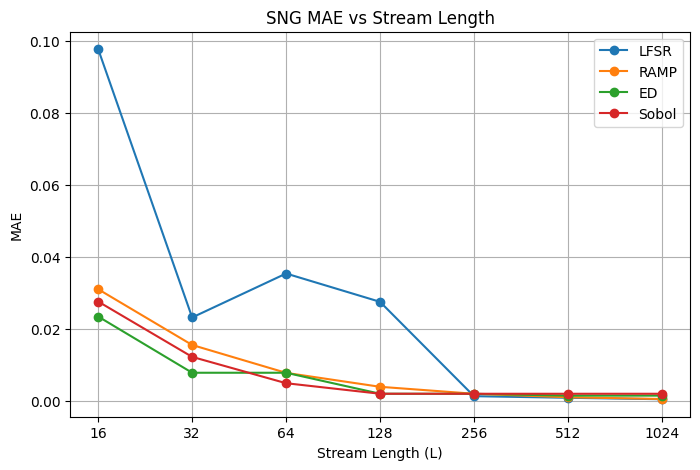

In [14]:
# ============================================================
# 7.2 MAE vs Stream Length
# ============================================================

plt.figure(figsize=(8, 5))

for sng_name in all_sng_summaries["SNG"].unique():

    data = all_sng_summaries[
        all_sng_summaries["SNG"] == sng_name
    ]

    plt.plot(
        data["L"],
        data["MAE"],
        marker="o",
        label=sng_name
    )

plt.xscale("log", base=2)
plt.xlabel("Stream Length (L)")
plt.ylabel("MAE")
plt.title("SNG MAE vs Stream Length")
plt.xticks(L_VALUES, L_VALUES)
plt.grid(True, which="both")
plt.legend()
plt.show()

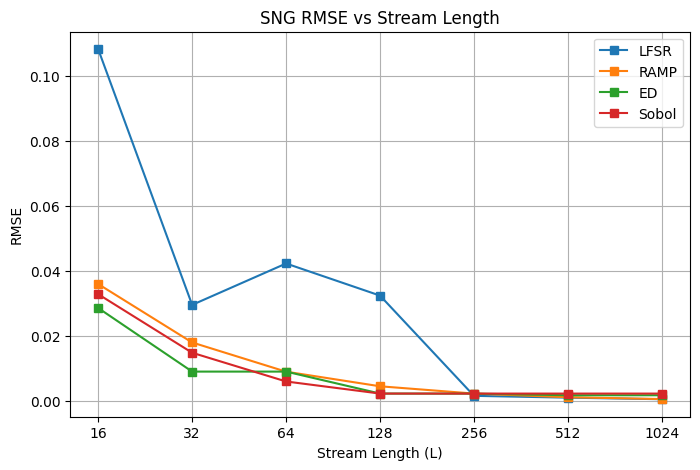

In [15]:
# ============================================================
# 7.3 RMSE vs Stream Length
# ============================================================

plt.figure(figsize=(8, 5))

for sng_name in all_sng_summaries["SNG"].unique():

    data = all_sng_summaries[
        all_sng_summaries["SNG"] == sng_name
    ]

    plt.plot(
        data["L"],
        data["RMSE"],
        marker="s",
        label=sng_name
    )

plt.xscale("log", base=2)
plt.xlabel("Stream Length (L)")
plt.ylabel("RMSE")
plt.title("SNG RMSE vs Stream Length")
plt.xticks(L_VALUES, L_VALUES)
plt.grid(True, which="both")
plt.legend()
plt.show()

## 8. Checkpoint

At this point the SNG representation study is complete.

The next stage is stochastic arithmetic:

1. 256 × 256 multiplication study
2. Exact binary product vs decoded stochastic product
3. Addition architectures
4. MAC architectures
5. Comparison with the 8×8 Booth multiplier
6. RTL implementation and Vivado area/power/timing analysis

## 8. Exhaustive Stochastic Multiplication Study

The SNG representation study is now extended to stochastic multiplication.

Four SNG architectures are compared:

- LFSR
- RAMP
- Even-Distribution (ED)
- Sobol / Quasirandom

For every architecture, two separate stochastic streams are generated,
one for each operand.

The complete unsigned 8-bit input space is evaluated:

$$
256 \times 256 = 65,536
$$

input pairs.

The study is repeated for:

$$
L \in \{16,32,64,128,256,512,1024\}
$$

### Stochastic multiplication

For input values $A$ and $B$:

$$
x = \frac{A}{255}
$$

$$
y = \frac{B}{255}
$$

The ideal normalized product is:

$$
P_{\mathrm{exact}} = xy
$$

The two stochastic streams are:

$$
S_A = SNG(A)
$$

$$
S_B = SNG(B)
$$

For unipolar stochastic multiplication, an AND gate is used:

$$
S_{\mathrm{out},i} = S_{A,i} \land S_{B,i}
$$

The stochastic product is estimated from the output one-density:

$$
P_{\mathrm{SC}}
=
\frac{1}{L}
\sum_{i=0}^{L-1}S_{\mathrm{out},i}
$$

The normalized multiplication error is:

$$
E =
P_{\mathrm{SC}} - P_{\mathrm{exact}}
$$

and the absolute error is:

$$
|E| =
|P_{\mathrm{SC}} - P_{\mathrm{exact}}|
$$

### Two independent SNG instances

The two operands must not accidentally use the same stochastic sequence.

For the LFSR architecture, the previously investigated configuration is retained:

```text
Operand A → P2, seed 198
Operand B → P2, seed 86

## 9. Two-Stream SNG Configuration for Multiplication

For stochastic multiplication, two stochastic streams are required:

$$
S_A = SNG_A(A)
$$

$$
S_B = SNG_B(B)
$$

The two streams are then multiplied bit-by-bit:

$$
S_{out,i} = S_{A,i} \land S_{B,i}
$$

The two operands are treated as separate SNG instances. The exact
configuration depends on the SNG architecture.

### LFSR

The previously investigated LFSR pair is retained:

| Operand | Polynomial | Seed |
|---|---|---:|
| A | P2 = `[7,5,4,1]` | 198 |
| B | P2 = `[7,5,4,1]` | 86 |

Thus the two operands use separate 8-bit LFSR states and different seeds.

### RAMP

RAMP has no random seed. Both operands use the same deterministic ramp
sequence:

$$
r_i = \frac{i}{L}
$$

but each operand uses its own input-dependent threshold:

$$
S_{A,i} = [r_i < A/255]
$$

$$
S_{B,i} = [r_i < B/255]
$$

This intentionally preserves the deterministic nature of RAMP. The
resulting stream relationship will be measured rather than assuming
statistical independence.

### ED

The two ED operands are generated as separate ED instances.

Each operand has its own intergroup and intragroup randomization sequence.
Independent control sequences are used for the two instances.

The verified ED configuration is:

- $B=1$
- $V=16$
- $K=4$
- 16 parallel output lines
- 15 swapper elements

### Sobol

Sobol is deterministic, so two operand streams are generated from the
same base Sobol construction but with separate stream-generation phases.

The two sequences are kept distinct so that the multiplication experiment
does not accidentally reuse one identical stochastic stream.

### Important principle

The multiplication experiment does not assume that all SNG architectures
produce statistically independent streams.

Instead, stream dependence is part of the experiment.

Therefore, for every architecture we measure both:

1. overall multiplication error; and
2. the dependence of the two generated streams.

This allows the effect of the SNG architecture on stochastic multiplication
to be studied directly.

In [16]:
# ============================================================
# Two-Stream SNG Framework for Multiplication
# ============================================================

# ------------------------------------------------------------
# LFSR
# ------------------------------------------------------------

LFSR_A_SEED = 198
LFSR_B_SEED = 86

def lfsr_sng_A(value, L):
    return lfsr_sng(value, L) if False else (
        np.zeros(L, dtype=int)
        if value == 0
        else (lfsr_sequence_with_seed(L, LFSR_A_SEED) <= value).astype(int)
    )


def lfsr_sng_B(value, L):
    return lfsr_sng(value, L) if False else (
        np.zeros(L, dtype=int)
        if value == 0
        else (lfsr_sequence_with_seed(L, LFSR_B_SEED) <= value).astype(int)
    )


def lfsr_sequence_with_seed(length, seed):
    state = seed
    sequence = []

    for _ in range(length):
        sequence.append(state)
        state = lfsr_next(state)

    return np.asarray(sequence, dtype=int)


# ------------------------------------------------------------
# RAMP
# ------------------------------------------------------------

def ramp_sng_A(value, L):
    probability = value / INPUT_MAX
    ramp = np.arange(L) / L

    return (ramp < probability).astype(int)


def ramp_sng_B(value, L):
    probability = value / INPUT_MAX
    ramp = np.arange(L) / L

    return (ramp < probability).astype(int)


# ------------------------------------------------------------
# ED
# ------------------------------------------------------------

ED_A_SEED = 42
ED_B_SEED = 43

def ed_sng_A(value, L):
    return ed_sng(value, L, seed=ED_A_SEED)


def ed_sng_B(value, L):
    return ed_sng(value, L, seed=ED_B_SEED)


# ------------------------------------------------------------
# Sobol
# ------------------------------------------------------------

def sobol_sng_phase(value, L, offset=0):

    value = int(value)

    if value == 0:
        return np.zeros(L, dtype=int)

    if value == 255:
        return np.ones(L, dtype=int)

    sequence = sobol_sequence(L + offset)

    sequence = sequence[offset:]

    sequence_8bit = sequence >> 24

    return (sequence_8bit < value).astype(int)


def sobol_sng_A(value, L):
    return sobol_sng_phase(value, L, offset=0)


def sobol_sng_B(value, L):
    return sobol_sng_phase(value, L, offset=1)


# ------------------------------------------------------------
# Common dictionary
# ------------------------------------------------------------

SNG_PAIRS = {
    "LFSR": (lfsr_sng_A, lfsr_sng_B),
    "RAMP": (ramp_sng_A, ramp_sng_B),
    "ED": (ed_sng_A, ed_sng_B),
    "Sobol": (sobol_sng_A, sobol_sng_B)
}

print("Two-stream SNG framework ready.")
print()

for name, (sng_A, sng_B) in SNG_PAIRS.items():
    print(f"{name:6s} : Operand A + Operand B")

Two-stream SNG framework ready.

LFSR   : Operand A + Operand B
RAMP   : Operand A + Operand B
ED     : Operand A + Operand B
Sobol  : Operand A + Operand B


## 10. Two-Stream Multiplication Sanity Check

Before performing the exhaustive $256 \times 256$ evaluation, a small
representative test is used to verify the complete multiplication path.

The test operands are:

$$
A=128,\qquad B=192
$$

Therefore:

$$
x=\frac{128}{255}
$$

$$
y=\frac{192}{255}
$$

and the exact normalized product is:

$$
P_{\mathrm{exact}}
=
\frac{128}{255}
\frac{192}{255}
$$

For each SNG architecture:

1. Generate stream $S_A$ for operand A.
2. Generate stream $S_B$ for operand B.
3. Perform bitwise AND.
4. Calculate the output one-density.
5. Compare it with the exact normalized product.

This test is only a functional check.

The actual accuracy study will later evaluate all

$$
256\times256=65,536
$$

input combinations for every stream length and every SNG architecture.

In [17]:
# ============================================================
# Two-Stream Multiplication Sanity Check
# ============================================================

A_TEST = 128
B_TEST = 192

print(f"Test inputs: A = {A_TEST}, B = {B_TEST}")
print()

for L in L_VALUES:

    exact = (
        A_TEST / INPUT_MAX
    ) * (
        B_TEST / INPUT_MAX
    )

    print(f"L = {L}")
    print("-" * 60)

    for name, (sng_A, sng_B) in SNG_PAIRS.items():

        stream_A = np.asarray(
            sng_A(A_TEST, L),
            dtype=int
        )

        stream_B = np.asarray(
            sng_B(B_TEST, L),
            dtype=int
        )

        stream_product = stream_A & stream_B

        p_A = np.mean(stream_A)
        p_B = np.mean(stream_B)
        p_product = np.mean(stream_product)

        error = abs(p_product - exact)

        print(
            f"{name:6s} | "
            f"P(A)={p_A:.6f} | "
            f"P(B)={p_B:.6f} | "
            f"P(A&B)={p_product:.6f} | "
            f"Error={error:.6f}"
        )

    print(
        f"Exact normalized product = {exact:.6f}\n"
    )

Test inputs: A = 128, B = 192

L = 16
------------------------------------------------------------
LFSR   | P(A)=0.562500 | P(B)=0.812500 | P(A&B)=0.500000 | Error=0.122053
RAMP   | P(A)=0.562500 | P(B)=0.812500 | P(A&B)=0.562500 | Error=0.184553
ED     | P(A)=0.500000 | P(B)=0.750000 | P(A&B)=0.437500 | Error=0.059553
Sobol  | P(A)=0.500000 | P(B)=0.750000 | P(A&B)=0.375000 | Error=0.002947
Exact normalized product = 0.377947

L = 32
------------------------------------------------------------
LFSR   | P(A)=0.500000 | P(B)=0.781250 | P(A&B)=0.375000 | Error=0.002947
RAMP   | P(A)=0.531250 | P(B)=0.781250 | P(A&B)=0.531250 | Error=0.153303
ED     | P(A)=0.500000 | P(B)=0.750000 | P(A&B)=0.437500 | Error=0.059553
Sobol  | P(A)=0.500000 | P(B)=0.750000 | P(A&B)=0.375000 | Error=0.002947
Exact normalized product = 0.377947

L = 64
------------------------------------------------------------
LFSR   | P(A)=0.515625 | P(B)=0.765625 | P(A&B)=0.406250 | Error=0.028303
RAMP   | P(A)=0.515625 | 

## 11. Exhaustive 256 x 256 Stochastic Multiplication Evaluation

The stochastic multiplier performs unipolar multiplication using a
bitwise AND operation.

For every clock position:

    S_product[i] = S_A[i] AND S_B[i]

For an 8-bit unsigned input:

    P_A = A / 255
    P_B = B / 255

Therefore, the ideal normalized product is:

    P_exact = (A / 255) x (B / 255)

For each SNG architecture and each stream length:

    L = 16, 32, 64, 128, 256, 512, 1024

all possible input combinations are evaluated.

There are:

    256 x 256 = 65,536

input combinations for every SNG and every stream length.

For each input pair, the following are calculated:

- Stochastic product
- Exact product
- Absolute error
- Representation error
- Dependence error

The overall evaluation reports:

- MAE: Mean Absolute Error
- RMSE: Root Mean Square Error
- Maximum Absolute Error
- Bias
- Mean Absolute Dependence Error
- Mean Absolute Representation Error

The stochastic product is also decoded back to the original integer
product range.

Decoded stochastic product:

    P_decoded = P_stochastic x 255^2

Exact integer product:

    P_exact_integer = A x B

This allows the stochastic multiplier to be evaluated both in the
normalized stochastic domain and in the original 8-bit x 8-bit
integer multiplication domain.

For the LFSR architecture, the previously selected P2-198 and P2-86
stream pair is kept fixed for all values of L. This allows the effect
of stream length to be studied without changing the LFSR configuration.

In [18]:
# ============================================================
# 11. Exhaustive 256 × 256 Stochastic Multiplication
# ============================================================

INPUTS = np.arange(256, dtype=int)

# Exact normalized operands
p_values = INPUTS / INPUT_MAX

# Exact normalized product for every A,B pair
exact_product = p_values[:, None] * p_values[None, :]

# Exact integer product
exact_integer_product = INPUTS[:, None] * INPUTS[None, :]

multiplication_results = []
multiplication_matrices = {}

for L in L_VALUES:

    print(f"Processing L = {L}")

    for name, (sng_A, sng_B) in SNG_PAIRS.items():

        # ----------------------------------------------------
        # Generate all 256 streams for operand A and B
        # ----------------------------------------------------
        streams_A = np.zeros((256, L), dtype=np.int8)
        streams_B = np.zeros((256, L), dtype=np.int8)

        for value in INPUTS:
            streams_A[value] = np.asarray(
                sng_A(int(value), L), dtype=np.int8
            )

            streams_B[value] = np.asarray(
                sng_B(int(value), L), dtype=np.int8
            )

        # ----------------------------------------------------
        # Bitwise AND multiplication
        #
        # Matrix multiplication computes:
        # streams_A[a] dot streams_B[b]
        #
        # = number of positions where both streams are 1
        # ----------------------------------------------------
        product_density = (
            streams_A.astype(np.float64)
            @ streams_B.astype(np.float64).T
        ) / L

        # ----------------------------------------------------
        # Errors in normalized domain
        # ----------------------------------------------------
        error = product_density - exact_product
        abs_error = np.abs(error)

        mae = np.mean(abs_error)
        rmse = np.sqrt(np.mean(error ** 2))
        max_error = np.max(abs_error)
        bias = np.mean(error)

        # ----------------------------------------------------
        # Dependence error
        #
        # Ideal relation:
        # P(A AND B) = P(A) * P(B)
        # ----------------------------------------------------
        p_A = np.mean(streams_A, axis=1)
        p_B = np.mean(streams_B, axis=1)

        dependence_error = (
            product_density - p_A[:, None] * p_B[None, :]
        )

        mean_abs_dependence_error = np.mean(
            np.abs(dependence_error)
        )

        # ----------------------------------------------------
        # Representation error
        # ----------------------------------------------------
        representation_error_A = np.mean(
            np.abs(p_A - p_values)
        )

        representation_error_B = np.mean(
            np.abs(p_B - p_values)
        )

        representation_error = (
            representation_error_A +
            representation_error_B
        ) / 2

        # ----------------------------------------------------
        # Decode stochastic product to original integer scale
        # ----------------------------------------------------
        decoded_product = product_density * (INPUT_MAX ** 2)

        decoded_error = (
            decoded_product - exact_integer_product
        )

        decoded_mae = np.mean(np.abs(decoded_error))
        decoded_rmse = np.sqrt(np.mean(decoded_error ** 2))
        decoded_max_error = np.max(np.abs(decoded_error))

        # ----------------------------------------------------
        # Save matrices for later heatmaps / analysis
        # ----------------------------------------------------
        multiplication_matrices[(name, L)] = {
            "product_density": product_density,
            "exact_product": exact_product,
            "error": error,
            "dependence_error": dependence_error,
            "decoded_product": decoded_product,
            "exact_integer_product": exact_integer_product
        }

        # ----------------------------------------------------
        # Save summary
        # ----------------------------------------------------
        multiplication_results.append({
            "SNG": name,
            "L": L,
            "MAE": mae,
            "RMSE": rmse,
            "Max_Error": max_error,
            "Bias": bias,
            "Mean_Abs_Dependence_Error":
                mean_abs_dependence_error,
            "Mean_Abs_Representation_Error":
                representation_error,
            "Decoded_MAE": decoded_mae,
            "Decoded_RMSE": decoded_rmse,
            "Decoded_Max_Error": decoded_max_error
        })

        print(
            f"  {name:6s} | "
            f"MAE={mae:.6f} | "
            f"RMSE={rmse:.6f} | "
            f"MAX={max_error:.6f}"
        )

print("\nExhaustive multiplication evaluation complete.")

multiplication_df = pd.DataFrame(multiplication_results)

multiplication_df

Processing L = 16
  LFSR   | MAE=0.069712 | RMSE=0.086346 | MAX=0.244590
  RAMP   | MAE=0.114747 | RMSE=0.132709 | MAX=0.310535
  ED     | MAE=0.042528 | RMSE=0.053631 | MAX=0.184003
  Sobol  | MAE=0.040969 | RMSE=0.049693 | MAX=0.149595
Processing L = 32
  LFSR   | MAE=0.019419 | RMSE=0.024673 | MAX=0.102477
  RAMP   | MAE=0.098877 | RMSE=0.118393 | MAX=0.279285
  ED     | MAE=0.034484 | RMSE=0.044661 | MAX=0.157367
  Sobol  | MAE=0.026995 | RMSE=0.033093 | MAX=0.104318
Processing L = 64
  LFSR   | MAE=0.032835 | RMSE=0.039563 | MAX=0.108886
  RAMP   | MAE=0.091065 | RMSE=0.111677 | MAX=0.263660
  ED     | MAE=0.033631 | RMSE=0.043547 | MAX=0.154369
  Sobol  | MAE=0.021133 | RMSE=0.026618 | MAX=0.080204
Processing L = 128
  LFSR   | MAE=0.031097 | RMSE=0.036470 | MAX=0.094664
  RAMP   | MAE=0.087189 | RMSE=0.108446 | MAX=0.255848
  ED     | MAE=0.032273 | RMSE=0.042050 | MAX=0.149109
  Sobol  | MAE=0.018900 | RMSE=0.024409 | MAX=0.068885
Processing L = 256
  LFSR   | MAE=0.002741 | RM

,SNG,L,MAE,RMSE,Max_Error,Bias,Mean_Abs_Dependence_Error,Mean_Abs_Representation_Error,Decoded_MAE,Decoded_RMSE,Decoded_Max_Error
0,LFSR,16,0.069712,0.086346,0.244590,0.053471,0.019016,0.076178,4533.025541,5614.666040,15904.437500
1,RAMP,16,0.114747,0.132709,0.310535,0.114747,0.082780,0.031006,7461.426759,8629.402351,20192.562500
2,ED,16,0.042528,0.053631,0.184003,-0.000916,0.039055,0.019485,2765.366684,3487.366046,11964.812500
3,Sobol,16,0.040969,0.049693,0.149595,0.034096,0.023544,0.027285,2664.035728,3231.257721,9727.437500
4,LFSR,32,0.019419,0.024673,0.102477,0.002570,0.023437,0.023517,1262.696807,1604.350598,6663.562500
5,RAMP,32,0.098877,0.118393,0.279285,0.098877,0.083134,0.015503,6429.504883,7698.528846,18160.531250
6,ED,32,0.034484,0.044661,0.157367,-0.000916,0.034085,0.007782,2242.294617,2904.099199,10232.812500
7,Sobol,32,0.026995,0.033093,0.104318,0.022253,0.020005,0.012167,1755.345989,2151.873328,6783.281250
8,LFSR,64,0.032835,0.039563,0.108886,0.029465,0.010962,0.031318,2135.109605,2572.558913,7080.328125
9,RAMP,64,0.091065,0.111677,0.263660,0.091065,0.083253,0.007751,5921.481568,7261.802646,17144.515625


## 12. LFSR Period and Stream-Length Check

The exhaustive multiplication results show a significant change in
LFSR multiplication error around L = 256.

Before interpreting this as an accuracy improvement, the periodic
behavior of the 8-bit LFSR must be examined.

The LFSR generator has a finite state space and therefore produces a
periodic sequence.

We will check:

- LFSR sequence period
- Number of unique states
- Behavior when L exceeds one period
- Stream statistics for the selected P2-198 and P2-86 streams

This check is necessary because the multiplication experiment uses
the same fixed LFSR seeds for every value of L.

In [19]:
# ============================================================
# 12. LFSR Period and Stream-Length Check
# ============================================================

def find_lfsr_period(seed, max_steps=1000):
    state = seed
    seen = {}

    for step in range(max_steps):
        if state in seen:
            return seen[state], step - seen[state]

        seen[state] = step
        state = lfsr_next(state)

    return None, None


for seed in [LFSR_A_SEED, LFSR_B_SEED]:

    start, period = find_lfsr_period(seed)

    print(f"Seed = {seed}")
    print(f"Cycle starts at index : {start}")
    print(f"Period                : {period}")
    print(f"Unique states         : {len(set(lfsr_sequence_with_seed(300, seed)))}")
    print()

Seed = 198
Cycle starts at index : 0
Period                : 255
Unique states         : 255

Seed = 86
Cycle starts at index : 0
Period                : 255
Unique states         : 255



## 13. Multiplication Accuracy vs Stream Length

The exhaustive multiplication experiment has now been completed for
all 65,536 input pairs.

This section visualizes how multiplication accuracy changes with
stochastic stream length.

The following metrics are examined:

- MAE: Mean Absolute Error
- RMSE: Root Mean Square Error
- Maximum Absolute Error

The comparison includes:

- LFSR
- RAMP
- ED
- Sobol

The purpose is to observe how increasing the stochastic stream length
affects multiplication accuracy for each SNG architecture.

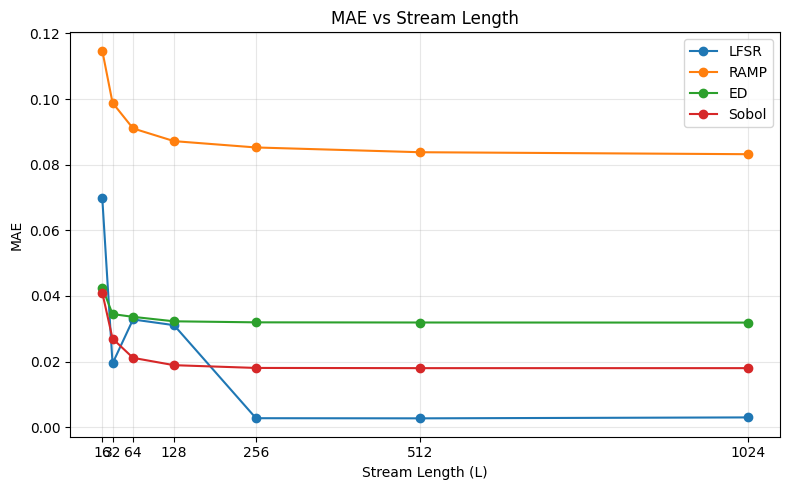

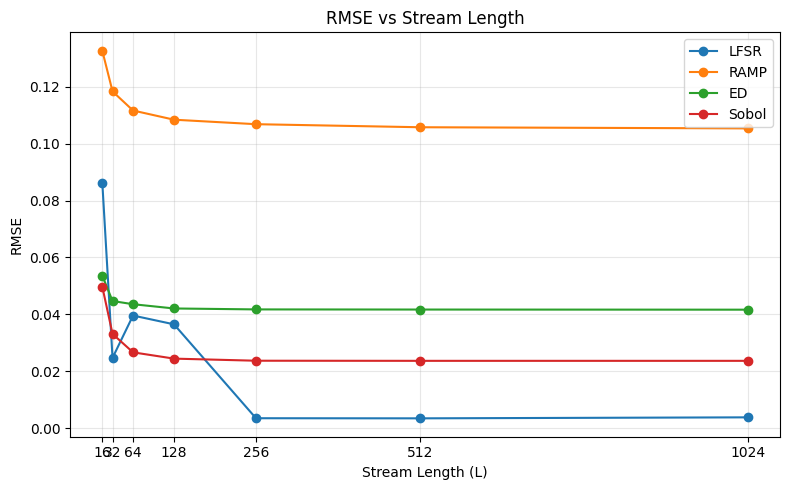

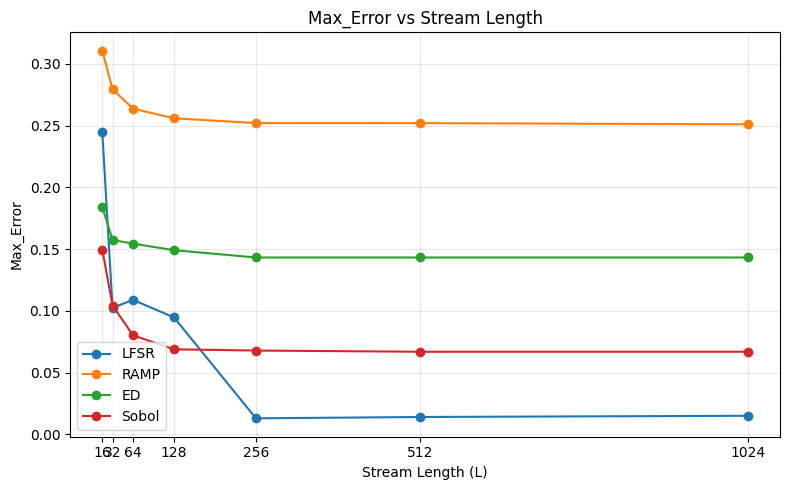

In [20]:
# ============================================================
# 13. Multiplication Accuracy vs Stream Length
# ============================================================

import matplotlib.pyplot as plt

metrics = ["MAE", "RMSE", "Max_Error"]

for metric in metrics:

    plt.figure(figsize=(8, 5))

    for name in SNG_PAIRS.keys():

        data = multiplication_df[
            multiplication_df["SNG"] == name
        ]

        plt.plot(
            data["L"],
            data[metric],
            marker="o",
            label=name
        )

    plt.xlabel("Stream Length (L)")
    plt.ylabel(metric)
    plt.title(f"{metric} vs Stream Length")
    plt.xticks(L_VALUES)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

## 14. Improved Visualization of Multiplication Accuracy

The stream lengths increase approximately by powers of two.

Therefore, a logarithmic x-axis is useful for visualizing the effect of
stream length.

Several complementary plots are used:

1. MAE vs stream length using logarithmic axes.
2. RMSE vs stream length using logarithmic axes.
3. Percentage reduction in MAE relative to L = 16.
4. Direct comparison of MAE for each stream length.

The logarithmic plots help reveal trends that are difficult to see on a
linear scale, especially because the LFSR error changes sharply around
L = 256.

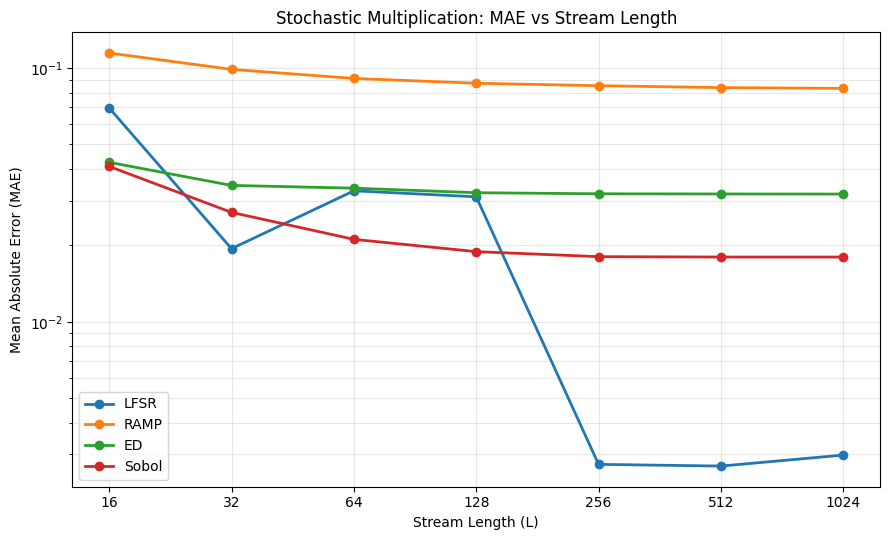

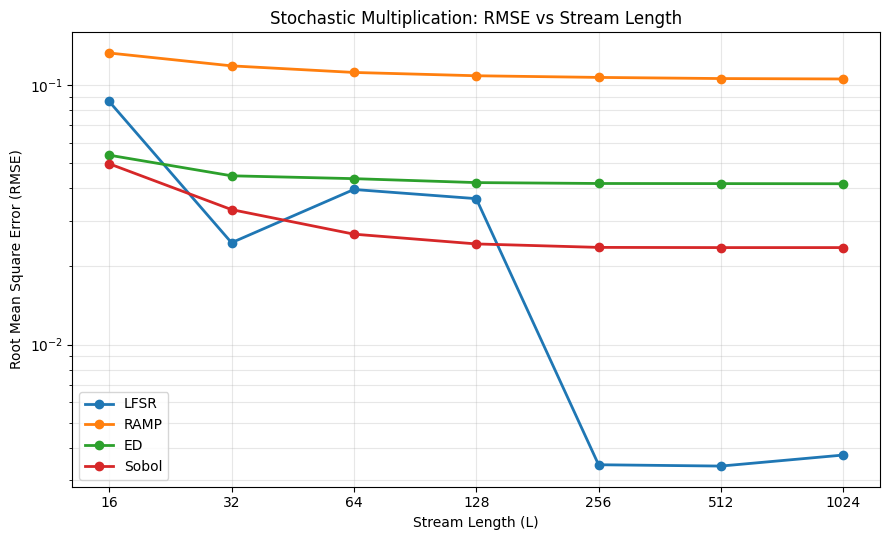

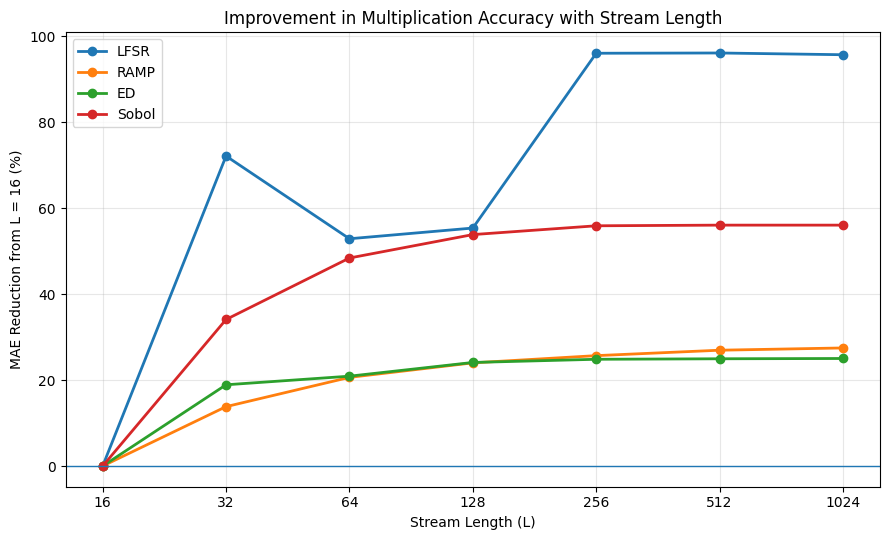

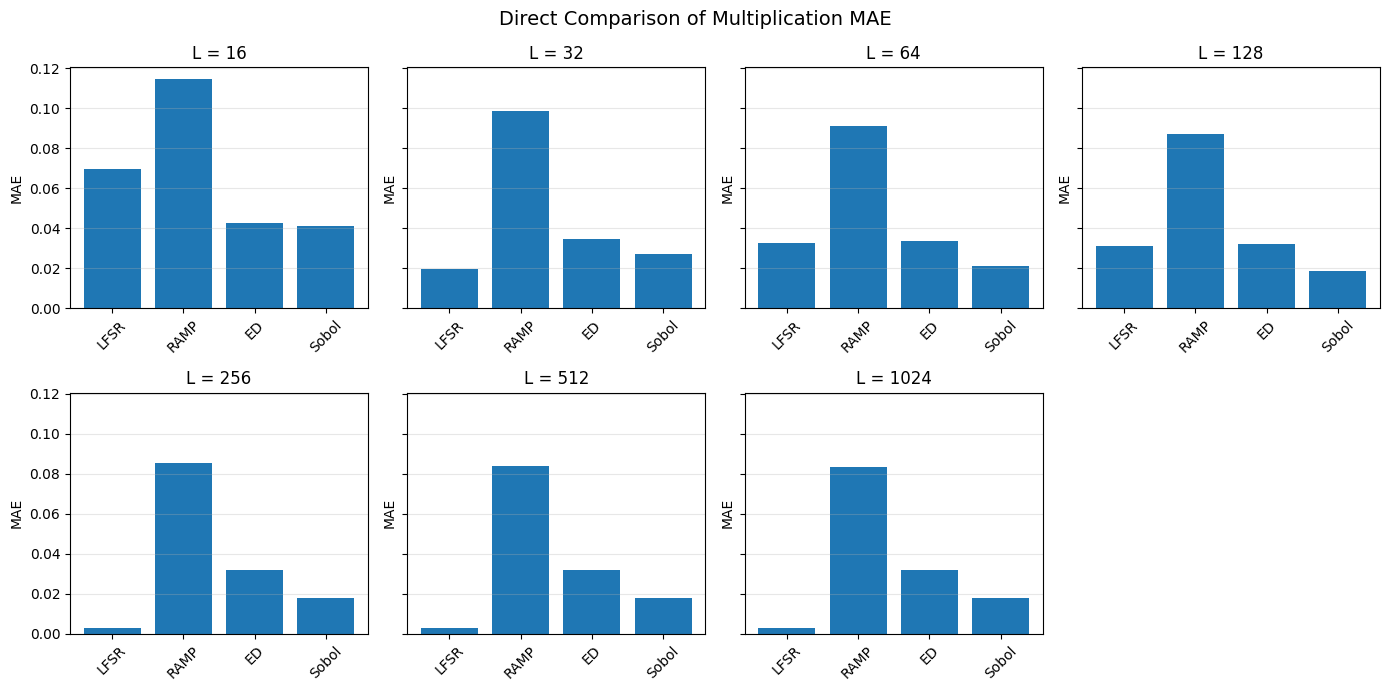

In [21]:
# ============================================================
# 14. Improved Multiplication Accuracy Plots
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# Plot 1: MAE vs L - log-log
# ------------------------------------------------------------

plt.figure(figsize=(9, 5.5))

for name in SNG_PAIRS.keys():

    data = multiplication_df[
        multiplication_df["SNG"] == name
    ]

    plt.plot(
        data["L"],
        data["MAE"],
        marker="o",
        linewidth=2,
        label=name
    )

plt.xscale("log", base=2)
plt.yscale("log")

plt.xlabel("Stream Length (L)")
plt.ylabel("Mean Absolute Error (MAE)")
plt.title("Stochastic Multiplication: MAE vs Stream Length")
plt.xticks(L_VALUES, L_VALUES)
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Plot 2: RMSE vs L - log-log
# ------------------------------------------------------------

plt.figure(figsize=(9, 5.5))

for name in SNG_PAIRS.keys():

    data = multiplication_df[
        multiplication_df["SNG"] == name
    ]

    plt.plot(
        data["L"],
        data["RMSE"],
        marker="o",
        linewidth=2,
        label=name
    )

plt.xscale("log", base=2)
plt.yscale("log")

plt.xlabel("Stream Length (L)")
plt.ylabel("Root Mean Square Error (RMSE)")
plt.title("Stochastic Multiplication: RMSE vs Stream Length")
plt.xticks(L_VALUES, L_VALUES)
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Plot 3: MAE reduction relative to L = 16
# ------------------------------------------------------------

plt.figure(figsize=(9, 5.5))

for name in SNG_PAIRS.keys():

    data = multiplication_df[
        multiplication_df["SNG"] == name
    ].copy()

    baseline = data.iloc[0]["MAE"]

    reduction = (
        (baseline - data["MAE"]) / baseline
    ) * 100

    plt.plot(
        data["L"],
        reduction,
        marker="o",
        linewidth=2,
        label=name
    )

plt.xscale("log", base=2)

plt.xlabel("Stream Length (L)")
plt.ylabel("MAE Reduction from L = 16 (%)")
plt.title("Improvement in Multiplication Accuracy with Stream Length")
plt.xticks(L_VALUES, L_VALUES)
plt.axhline(0, linewidth=1)
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Plot 4: Direct MAE comparison for every L
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2, 4,
    figsize=(14, 7),
    sharey=True
)

axes = axes.flatten()

for i, L in enumerate(L_VALUES):

    data = multiplication_df[
        multiplication_df["L"] == L
    ]

    axes[i].bar(
        data["SNG"],
        data["MAE"]
    )

    axes[i].set_title(f"L = {L}")
    axes[i].set_ylabel("MAE")
    axes[i].tick_params(axis="x", rotation=45)
    axes[i].grid(axis="y", alpha=0.3)

# Remove unused 8th subplot
axes[-1].axis("off")

plt.suptitle(
    "Direct Comparison of Multiplication MAE",
    fontsize=14
)

plt.tight_layout()
plt.show()

# 9. Stochastic Addition: OR vs MUX

This section evaluates stochastic addition for all possible pairs of 8-bit input values.

The input values are

$$
A,B \in [0,255]
$$

Therefore, the total number of input combinations is

$$
256 \times 256 = 65,536.
$$

## 9.1 Stochastic MUX Addition

For two unipolar stochastic numbers $X$ and $Y$, a $2:1$ multiplexer can be used to perform scaled addition.

The MUX operates as

$$
Z =
\begin{cases}
X, & S=0,\\
Y, & S=1.
\end{cases}
$$

A deterministic 50% select sequence is used:

$$
S = 1010101010101010\ldots
$$

Therefore,

$$
P(S=1)=\frac{1}{2}.
$$

The probability of obtaining a `1` at the MUX output is

$$
P(Z)
=
P(S=0)P(X)
+
P(S=1)P(Y).
$$

Since

$$
P(S=0)=P(S=1)=\frac{1}{2},
$$

we obtain

$$
P(Z)
=
\frac{P(X)+P(Y)}{2}.
$$

Therefore, the MUX implements **scaled stochastic addition**:

$$
\boxed{
Z=\frac{X+Y}{2}
}
$$

The original normalized sum can be recovered as

$$
\boxed{
X+Y=2Z
}
$$

---

## 9.2 OR-Based Stochastic Operation

An OR gate is also evaluated for comparison.

For independent stochastic streams,

$$
P(X \lor Y)
=
P(X)+P(Y)-P(X)P(Y).
$$

Therefore,

$$
\boxed{
P(X \lor Y)=X+Y-XY
}
$$

Hence, an OR gate does **not** implement addition.

The OR implementation is included to demonstrate the difference between a conventional logic operation and a stochastic addition operation.

---

## 9.3 Stochastic Number Generators

The experiment is performed using the following stochastic number generators:

1. LFSR
2. Even Distribution (ED)
3. Sobol

The RAMP-based stochastic number generator is intentionally excluded.

---

## 9.4 Input Representation

The 8-bit binary input value is converted into a normalized unipolar stochastic value as

$$
X=\frac{A}{255}
$$

and

$$
Y=\frac{B}{255}.
$$

For the MUX-based stochastic adder, the ideal output is therefore

$$
Z_{\mathrm{ideal}}
=
\frac{X+Y}{2}.
$$

Substituting the normalized input values,

$$
Z_{\mathrm{ideal}}
=
\frac{1}{2}
\left(
\frac{A}{255}
+
\frac{B}{255}
\right).
$$

Therefore,

$$
\boxed{
Z_{\mathrm{ideal}}
=
\frac{A+B}{510}
}
$$

---

## 9.5 Evaluation

For each SNG and each stochastic stream length, all possible input pairs are evaluated:

$$
(A,B)\in[0,255]\times[0,255].
$$

This gives

$$
256\times256=65,536
$$

different input combinations.

For every input pair, the following quantities are calculated:

- MUX output probability
- OR output probability
- Ideal scaled sum
- MUX absolute error
- OR absolute error
- MUX MAE
- MUX RMSE
- OR MAE
- OR RMSE
- Maximum absolute error

The absolute error is defined as

$$
E_{\mathrm{abs}}
=
\left|
Z_{\mathrm{measured}}
-
Z_{\mathrm{ideal}}
\right|.
$$

The mean absolute error is

$$
\mathrm{MAE}
=
\frac{1}{N}
\sum_{i=1}^{N}
\left|
Z_i-Z_{\mathrm{ideal},i}
\right|.
$$

The root mean square error is

$$
\mathrm{RMSE}
=
\sqrt{
\frac{1}{N}
\sum_{i=1}^{N}
\left(
Z_i-Z_{\mathrm{ideal},i}
\right)^2
}.
$$

---

## 9.6 Error Visualization

For each SNG, a $256\times256$ error matrix is generated.

The row corresponds to input $A$ and the column corresponds to input $B$.

Thus, every point in the heatmap represents one of the $65,536$ possible input combinations.

The experiment also compares the MAE and RMSE as a function of stochastic stream length.

The expected behavior is that increasing the stochastic stream length reduces the stochastic estimation error.

However, increasing the stream length does not remove the fundamental mathematical difference between OR and addition:

$$
\text{MUX:}
\qquad
\frac{X+Y}{2}
$$

whereas

$$
\text{OR:}
\qquad
X+Y-XY.
$$

Therefore, the experiment distinguishes between **stochastic estimation error** and **operation-level mathematical error**.

In [22]:
# ============================================================
# 9. STOCHASTIC ADDITION: MUX vs OR
# ============================================================
#
# Architectures:
#   1. MUX
#      Raw output       = (X + Y) / 2
#      Recovered output = 2 * Raw MUX output
#
#   2. OR
#      Output = X + Y - XY
#
# SNGs:
#   - LFSR
#   - ED
#   - Sobol
#
# Input space:
#   256 x 256 = 65,536 input pairs
#
# No RAMP is used.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. Configuration
# ============================================================

INPUT_VALUES = np.arange(256)
NORMALIZED_VALUES = INPUT_VALUES / 255.0

# Use your existing L_VALUES if already defined.
# Otherwise uncomment the next line.
#
# L_VALUES = [16, 32, 64, 128, 256]

ADDITION_SNGS = {
    "LFSR": lfsr_sng,
    "ED": ed_sng,
    "Sobol": sobol_sng
}


# ============================================================
# 2. Deterministic 50% Select Sequence
# ============================================================
#
# 101010101010...
#
# 0 -> select X
# 1 -> select Y
#
# Exactly 50% of the bits are 1.
# ============================================================

def deterministic_select(L):

    select = np.zeros(L, dtype=np.int8)

    select[::2] = 1

    return select


# ============================================================
# 3. Generate all 256 stochastic streams
# ============================================================

def generate_all_streams(sng_function, L):

    streams = np.zeros(
        (256, L),
        dtype=np.int8
    )

    for value in range(256):

        streams[value] = np.asarray(
            sng_function(value, L),
            dtype=np.int8
        )

    return streams


# ============================================================
# 4. MUX Addition
# ============================================================
#
# Raw MUX:
#
#       Z = (X + Y) / 2
#
# Recovered:
#
#       Z_recovered = 2Z
#
# ============================================================

def mux_addition(streams):

    L = streams.shape[1]

    select = deterministic_select(L)

    # Select X when S = 0
    x_positions = (select == 0)

    # Select Y when S = 1
    y_positions = (select == 1)

    # Number of selected 1s from X
    x_selected_ones = streams[:, x_positions].sum(axis=1)

    # Number of selected 1s from Y
    y_selected_ones = streams[:, y_positions].sum(axis=1)

    # --------------------------------------------------------
    # Every possible A,B pair
    # --------------------------------------------------------

    output_ones = (
        x_selected_ones[:, None]
        +
        y_selected_ones[None, :]
    )

    # --------------------------------------------------------
    # Raw MUX stochastic probability
    # --------------------------------------------------------

    mux_raw = output_ones / L

    # --------------------------------------------------------
    # Recover X + Y
    # --------------------------------------------------------

    mux_recovered = 2.0 * mux_raw

    return mux_raw, mux_recovered


# ============================================================
# 5. OR Operation
# ============================================================

def or_operation(streams):

    L = streams.shape[1]

    # Number of positions where both streams are zero
    zero_streams = 1 - streams

    both_zero = (
        zero_streams @ zero_streams.T
    )

    # P(A OR B)
    or_output = 1.0 - (both_zero / L)

    return or_output


# ============================================================
# 6. Ideal Mathematical Values
# ============================================================

X = NORMALIZED_VALUES
Y = NORMALIZED_VALUES

# ------------------------------------------------------------
# Ideal scaled addition
#
# (X + Y) / 2
# ------------------------------------------------------------

ideal_scaled = (
    X[:, None] +
    Y[None, :]
) / 2.0


# ------------------------------------------------------------
# Ideal normal addition
#
# X + Y
# ------------------------------------------------------------

ideal_sum = (
    X[:, None] +
    Y[None, :]
)


# ============================================================
# 7. Storage
# ============================================================

addition_results = {}

summary_rows = []


# ============================================================
# 8. Main Experiment
# ============================================================

for sng_name, sng_function in ADDITION_SNGS.items():

    print()
    print("=" * 80)
    print(f"SNG: {sng_name}")
    print("=" * 80)

    addition_results[sng_name] = {}

    for L in L_VALUES:

        print(f"Running L = {L} ...", end=" ")

        # ----------------------------------------------------
        # Generate all 256 stochastic streams
        # ----------------------------------------------------

        streams = generate_all_streams(
            sng_function,
            L
        )

        # ----------------------------------------------------
        # MUX
        # ----------------------------------------------------

        mux_raw, mux_recovered = mux_addition(
            streams
        )

        # ----------------------------------------------------
        # OR
        # ----------------------------------------------------

        or_output = or_operation(
            streams
        )

        # ====================================================
        # MUX RAW ERROR
        #
        # Compare:
        #
        # measured (X+Y)/2
        #
        # against
        #
        # ideal (X+Y)/2
        # ====================================================

        mux_raw_error = (
            mux_raw -
            ideal_scaled
        )

        mux_raw_abs_error = np.abs(
            mux_raw_error
        )

        # ====================================================
        # MUX RECOVERED ERROR
        #
        # Compare:
        #
        # 2 * MUX
        #
        # against
        #
        # X + Y
        # ====================================================

        mux_recovered_error = (
            mux_recovered -
            ideal_sum
        )

        mux_recovered_abs_error = np.abs(
            mux_recovered_error
        )

        # ====================================================
        # OR ERROR
        #
        # Compare OR with ideal X+Y.
        #
        # IMPORTANT:
        #
        # OR is NOT a true adder.
        #
        # ====================================================

        or_error = (
            or_output -
            ideal_sum
        )

        or_abs_error = np.abs(
            or_error
        )

        # ----------------------------------------------------
        # Store everything
        # ----------------------------------------------------

        addition_results[sng_name][L] = {

            "streams": streams,

            "MUX_raw": mux_raw,

            "MUX_recovered": mux_recovered,

            "OR": or_output,

            "MUX_raw_error": mux_raw_error,

            "MUX_recovered_error":
                mux_recovered_error,

            "OR_error": or_error,

            "MUX_raw_abs_error":
                mux_raw_abs_error,

            "MUX_recovered_abs_error":
                mux_recovered_abs_error,

            "OR_abs_error":
                or_abs_error
        }

        # ====================================================
        # Summary metrics
        # ====================================================

        summary_rows.append({

            "SNG": sng_name,
            "L": L,

            "MUX_Raw_MAE":
                mux_raw_abs_error.mean(),

            "MUX_Raw_RMSE":
                np.sqrt(
                    np.mean(
                        mux_raw_error ** 2
                    )
                ),

            "MUX_Recovered_MAE":
                mux_recovered_abs_error.mean(),

            "MUX_Recovered_RMSE":
                np.sqrt(
                    np.mean(
                        mux_recovered_error ** 2
                    )
                ),

            "MUX_Recovered_Max":
                mux_recovered_abs_error.max(),

            "OR_MAE":
                or_abs_error.mean(),

            "OR_RMSE":
                np.sqrt(
                    np.mean(
                        or_error ** 2
                    )
                ),

            "OR_Max":
                or_abs_error.max()
        })

        print("Done")


# ============================================================
# 9. Summary Table
# ============================================================

addition_summary_df = pd.DataFrame(
    summary_rows
)

print()
print("=" * 100)
print("STOCHASTIC ADDITION RESULTS")
print("=" * 100)

display(
    addition_summary_df.style.format({
        "MUX_Raw_MAE": "{:.8f}",
        "MUX_Raw_RMSE": "{:.8f}",
        "MUX_Recovered_MAE": "{:.8f}",
        "MUX_Recovered_RMSE": "{:.8f}",
        "MUX_Recovered_Max": "{:.8f}",
        "OR_MAE": "{:.8f}",
        "OR_RMSE": "{:.8f}",
        "OR_Max": "{:.8f}"
    })
)


SNG: LFSR
Running L = 16 ... Done
Running L = 32 ... Done
Running L = 64 ... Done
Running L = 128 ... Done
Running L = 256 ... Done
Running L = 512 ... Done
Running L = 1024 ... Done

SNG: ED
Running L = 16 ... Done
Running L = 32 ... Done
Running L = 64 ... Done
Running L = 128 ... Done
Running L = 256 ... Done
Running L = 512 ... Done
Running L = 1024 ... Done

SNG: Sobol
Running L = 16 ... Done
Running L = 32 ... Done
Running L = 64 ... Done
Running L = 128 ... Done
Running L = 256 ... Done
Running L = 512 ... Done
Running L = 1024 ... Done

STOCHASTIC ADDITION RESULTS


,SNG,L,MUX_Raw_MAE,MUX_Raw_RMSE,MUX_Recovered_MAE,MUX_Recovered_RMSE,MUX_Recovered_Max,OR_MAE,OR_RMSE,OR_Max
0,LFSR,16,0.09789245,0.10973166,0.19578491,0.21946332,0.55735294,0.27152312,0.35328026,1.00000000
1,LFSR,32,0.02938985,0.03576742,0.05877971,0.07153485,0.21617647,0.31267136,0.39227959,1.00000000
2,LFSR,64,0.03170119,0.03815306,0.06340238,0.07630611,0.23664216,0.32125008,0.40488765,1.00000000
3,LFSR,128,0.02778630,0.03356067,0.05557261,0.06712134,0.18756127,0.31233275,0.39509530,2.00000000
4,LFSR,256,0.00796030,0.00977408,0.01592060,0.01954816,0.06170343,0.50233434,0.57951691,1.00000000
5,LFSR,512,0.00082926,0.00101283,0.00165852,0.00202566,0.00514706,0.37585099,0.45799390,1.00000000
6,LFSR,1024,0.00048276,0.00059184,0.00096553,0.00118368,0.00333180,0.34440819,0.42165503,1.00059360
7,ED,16,0.06628502,0.08218806,0.13257003,0.16437611,0.52794118,0.27032543,0.36910618,1.03112745
8,ED,32,0.05832879,0.07272932,0.11665757,0.14545864,0.46519608,0.26442253,0.36573848,1.00000000
9,ED,64,0.05832879,0.07272932,0.11665757,0.14545864,0.46519608,0.26442253,0.36573848,1.00000000


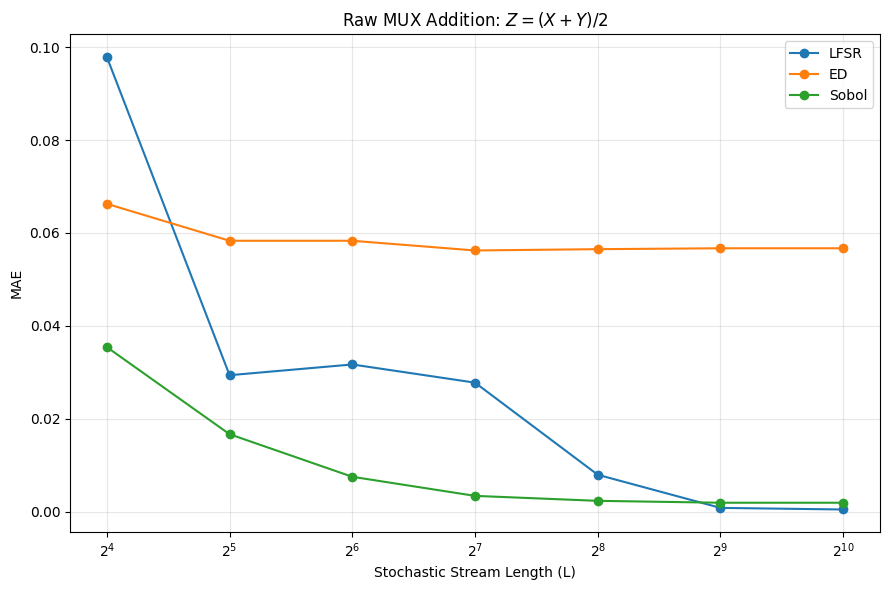

In [23]:
# ============================================================
# 10. RAW MUX OUTPUT ERROR
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 6)
)

for sng_name in ADDITION_SNGS.keys():

    data = addition_summary_df[
        addition_summary_df["SNG"] == sng_name
    ]

    ax.plot(
        data["L"],
        data["MUX_Raw_MAE"],
        marker="o",
        label=sng_name
    )

ax.set_xscale("log", base=2)

ax.set_xlabel("Stochastic Stream Length (L)")
ax.set_ylabel("MAE")

ax.set_title(
    "Raw MUX Addition: $Z = (X+Y)/2$"
)

ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

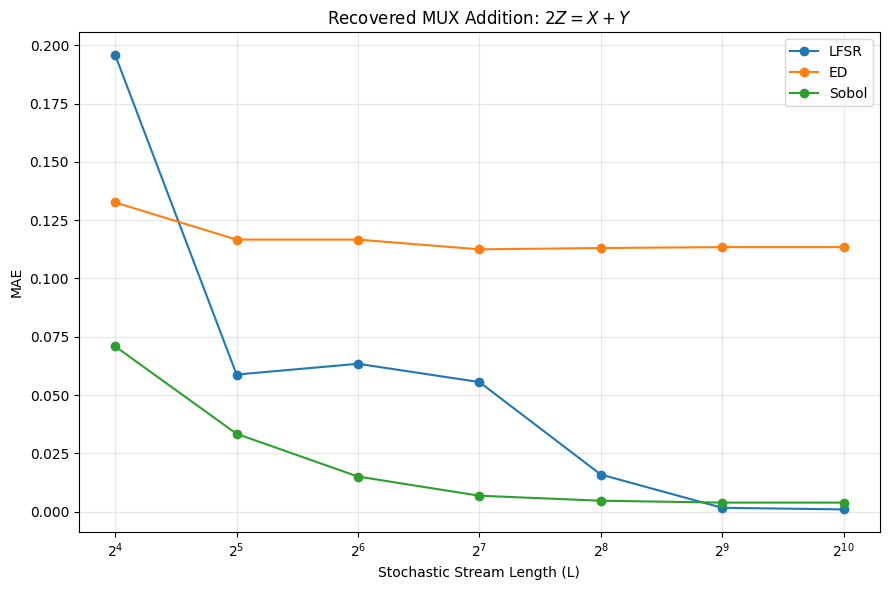

In [24]:
# ============================================================
# 11. RECOVERED MUX ADDITION
# ============================================================
#
# Recovered result:
#
#       Z_recovered = 2 * Z_MUX
#
# Ideal:
#
#       X + Y
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 6)
)

for sng_name in ADDITION_SNGS.keys():

    data = addition_summary_df[
        addition_summary_df["SNG"] == sng_name
    ]

    ax.plot(
        data["L"],
        data["MUX_Recovered_MAE"],
        marker="o",
        label=sng_name
    )

ax.set_xscale("log", base=2)

ax.set_xlabel("Stochastic Stream Length (L)")
ax.set_ylabel("MAE")

ax.set_title(
    "Recovered MUX Addition: $2Z = X+Y$"
)

ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

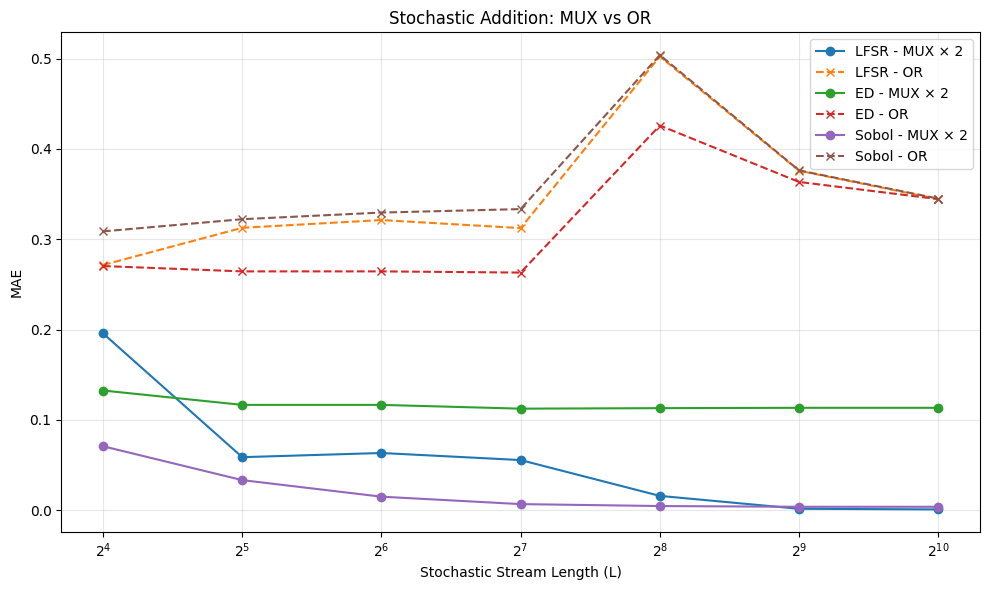

In [25]:
# ============================================================
# 12. MUX vs OR
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 6)
)

for sng_name in ADDITION_SNGS.keys():

    data = addition_summary_df[
        addition_summary_df["SNG"] == sng_name
    ]

    ax.plot(
        data["L"],
        data["MUX_Recovered_MAE"],
        marker="o",
        label=f"{sng_name} - MUX × 2"
    )

    ax.plot(
        data["L"],
        data["OR_MAE"],
        marker="x",
        linestyle="--",
        label=f"{sng_name} - OR"
    )


ax.set_xscale("log", base=2)

ax.set_xlabel("Stochastic Stream Length (L)")
ax.set_ylabel("MAE")

ax.set_title(
    "Stochastic Addition: MUX vs OR"
)

ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

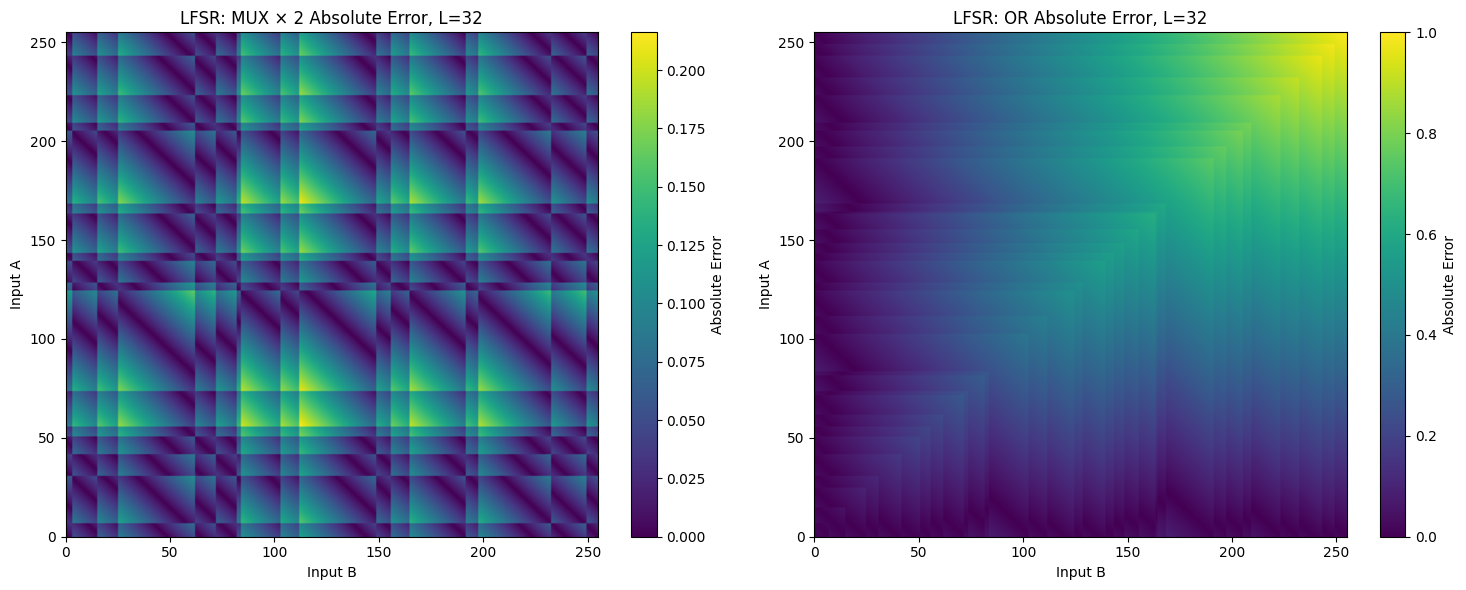

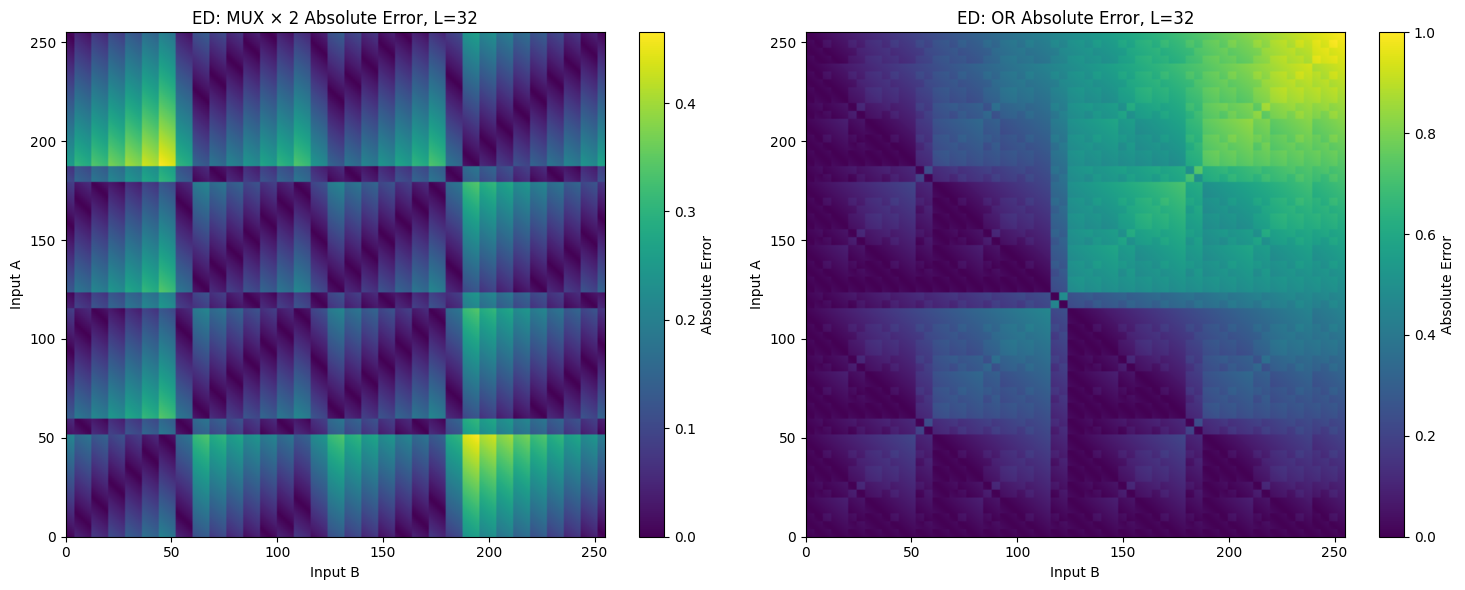

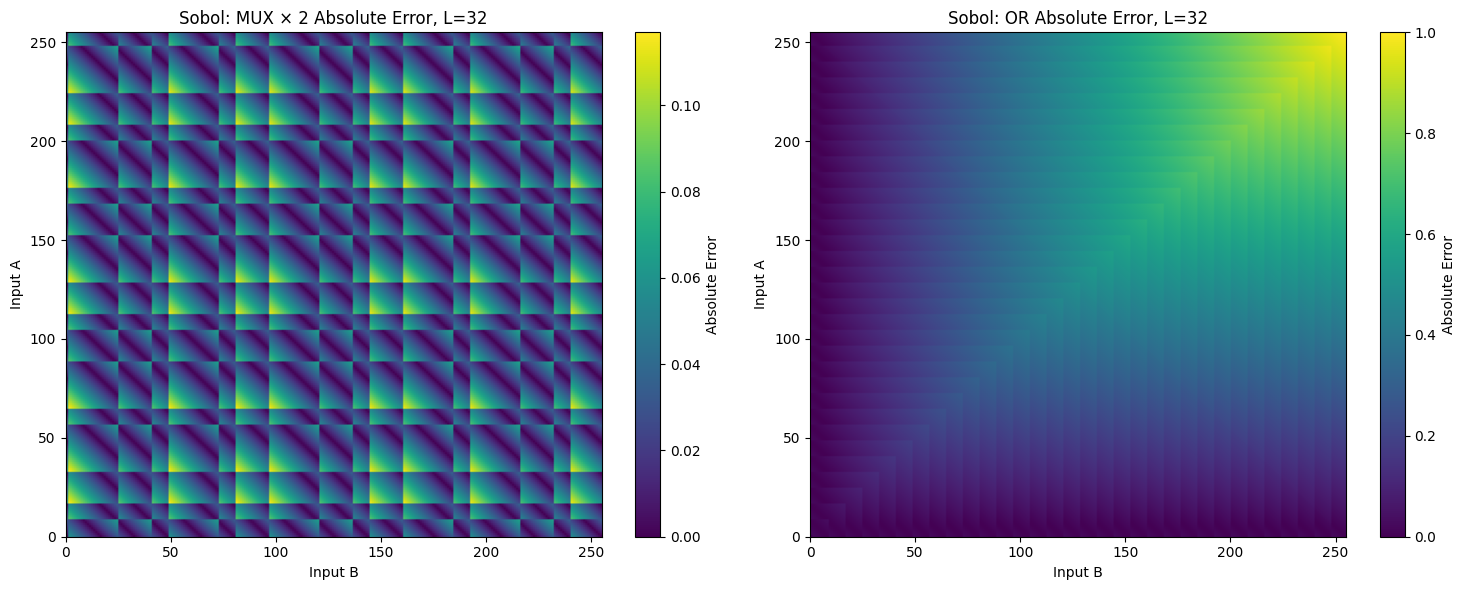

In [26]:
# ============================================================
# 13. 256 x 256 INPUT-SPACE ERROR MAP
# ============================================================

HEATMAP_L = 32


for sng_name in ADDITION_SNGS.keys():

    results = addition_results[sng_name][HEATMAP_L]

    mux_error = results[
        "MUX_recovered_abs_error"
    ]

    or_error = results[
        "OR_abs_error"
    ]

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(15, 6)
    )

    # --------------------------------------------------------
    # MUX
    # --------------------------------------------------------

    im1 = axes[0].imshow(
        mux_error,
        origin="lower",
        extent=[0, 255, 0, 255],
        aspect="auto"
    )

    axes[0].set_title(
        f"{sng_name}: MUX × 2 Absolute Error, L={HEATMAP_L}"
    )

    axes[0].set_xlabel("Input B")
    axes[0].set_ylabel("Input A")

    plt.colorbar(
        im1,
        ax=axes[0],
        label="Absolute Error"
    )

    # --------------------------------------------------------
    # OR
    # --------------------------------------------------------

    im2 = axes[1].imshow(
        or_error,
        origin="lower",
        extent=[0, 255, 0, 255],
        aspect="auto"
    )

    axes[1].set_title(
        f"{sng_name}: OR Absolute Error, L={HEATMAP_L}"
    )

    axes[1].set_xlabel("Input B")
    axes[1].set_ylabel("Input A")

    plt.colorbar(
        im2,
        ax=axes[1],
        label="Absolute Error"
    )

    plt.tight_layout()
    plt.show()

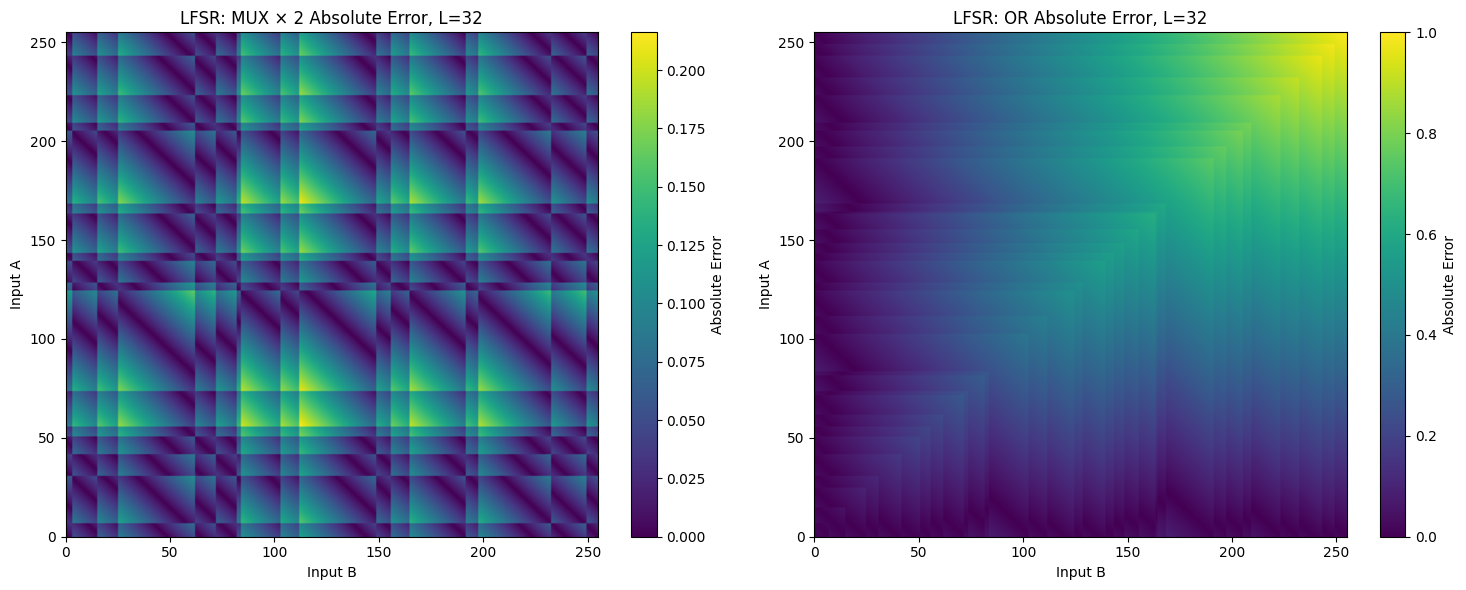

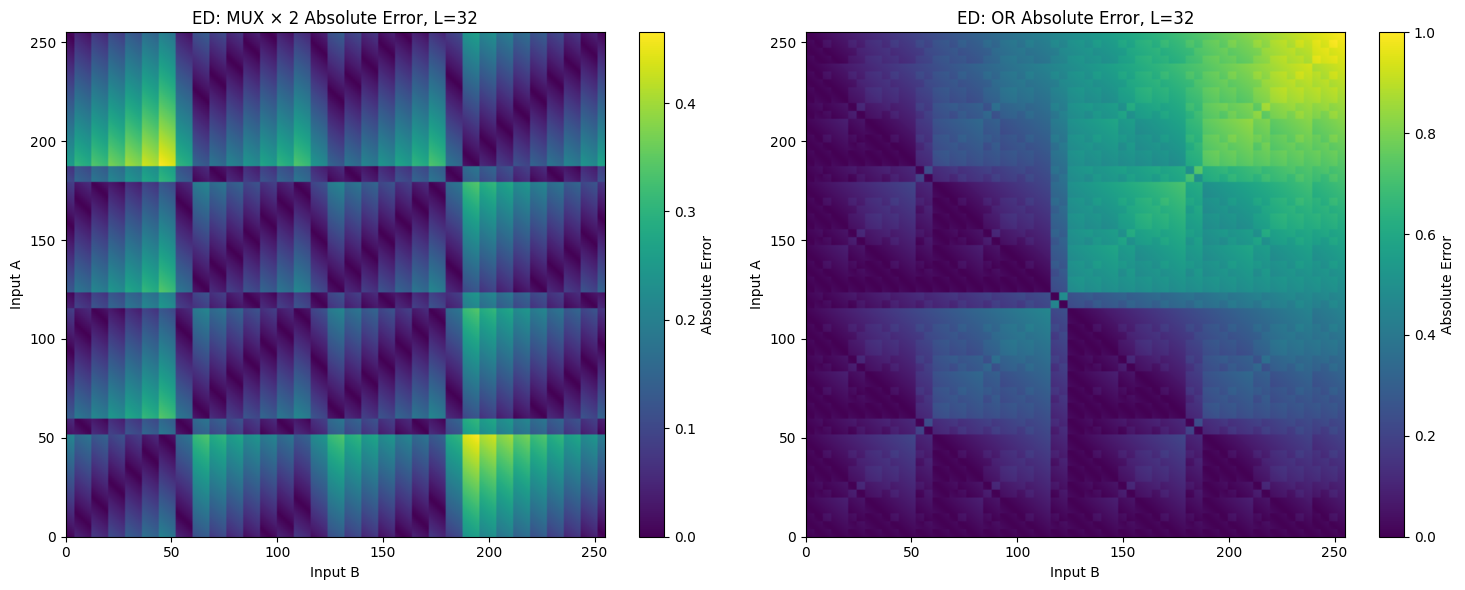

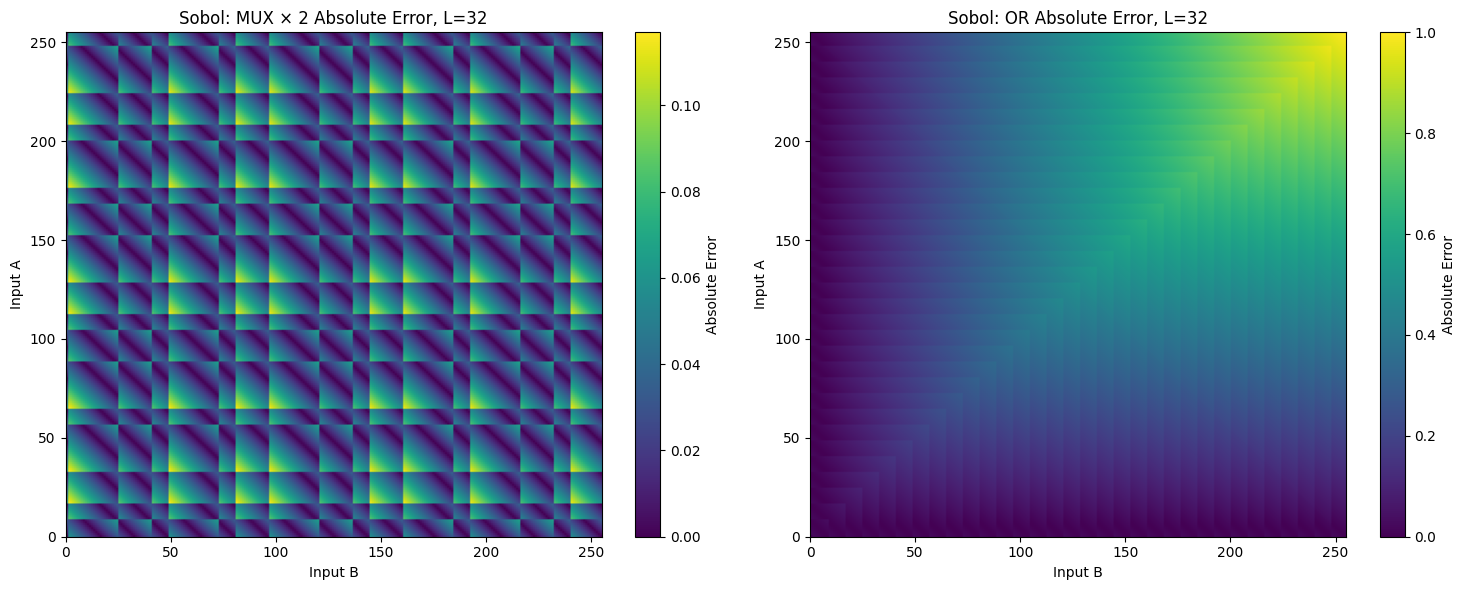

In [27]:
# ============================================================
# 13. 256 x 256 INPUT-SPACE ERROR MAP
# ============================================================

HEATMAP_L = 32


for sng_name in ADDITION_SNGS.keys():

    results = addition_results[sng_name][HEATMAP_L]

    mux_error = results[
        "MUX_recovered_abs_error"
    ]

    or_error = results[
        "OR_abs_error"
    ]

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(15, 6)
    )

    # --------------------------------------------------------
    # MUX
    # --------------------------------------------------------

    im1 = axes[0].imshow(
        mux_error,
        origin="lower",
        extent=[0, 255, 0, 255],
        aspect="auto"
    )

    axes[0].set_title(
        f"{sng_name}: MUX × 2 Absolute Error, L={HEATMAP_L}"
    )

    axes[0].set_xlabel("Input B")
    axes[0].set_ylabel("Input A")

    plt.colorbar(
        im1,
        ax=axes[0],
        label="Absolute Error"
    )

    # --------------------------------------------------------
    # OR
    # --------------------------------------------------------

    im2 = axes[1].imshow(
        or_error,
        origin="lower",
        extent=[0, 255, 0, 255],
        aspect="auto"
    )

    axes[1].set_title(
        f"{sng_name}: OR Absolute Error, L={HEATMAP_L}"
    )

    axes[1].set_xlabel("Input B")
    axes[1].set_ylabel("Input A")

    plt.colorbar(
        im2,
        ax=axes[1],
        label="Absolute Error"
    )

    plt.tight_layout()
    plt.show()